# Phase 2 - Part A: Unsupervised Learning (Clustering)

**Project:** Loan Approval Prediction  
**Group 3** - SWE485, Spring 1447

In Phase 1 we built a supervised pipeline that predicts `loan_status` (Approved / Rejected) from an applicant's financial profile. In Phase 2 we move beyond prediction and explore the **hidden structure** of the applicant population with clustering. The goal is to discover natural groupings of borrowers that our advice system can use to tailor its recommendations (e.g. strong approvals, borderline applicants, high-risk profiles) instead of returning a single yes/no label.

## Notebook outline
1. Clustering Rationale & Algorithm Selection
2. Data Preparation (target removal, feature scaling)
3. Cluster Determination (elbow method, silhouette analysis, dendrogram)
4. Implementation (K-Means and Agglomerative Clustering)
5. Evaluation Metrics & Visualizations (internal + external, PCA / t-SNE)
6. Cluster Interpretation & Profiles
7. Integration Strategy
8. Challenges & Limitations

## 1. Clustering Rationale & Algorithm Selection

### Why clustering on this dataset?
The preprocessed loan dataset contains **4,269 applicants** described by **14 features** fed to the scaler and clusterer (plus the `loan_status` label, used only for external checks). Most features are continuous financial indicators (income, loan amount, assets, engineered ratios). The remainder are discrete or ordinal—education, self-employment, number of dependents, and **`cibil_category`**, i.e. Phase 1’s binned credit bands (Poor / Average / Good) derived from the raw CIBIL score, which is **omitted** from this CSV on purpose. There is no obvious, domain-given segmentation of applicants beyond the approval label, which makes unsupervised learning a natural fit for discovering **sub-populations**—for example "high-income / high-asset", "low `cibil_category` band", or "high-leverage" borrowers—that the bank can treat differently.

### Algorithms chosen (two required by the rubric)| Algorithm | Family | Cluster shape assumption | Why it fits our data |
|-----------|--------|--------------------------|----------------------|
| **K-Means** | Centroid-based (partitional) | Compact, roughly spherical in scaled space | Scales to 4k rows and 14 numeric features easily, produces interpretable centroids (average applicant profile per cluster), and is the de-facto baseline for tabular numeric data. |
| **Agglomerative Clustering (Ward linkage)** | Hierarchical | No global shape assumption; merges close points bottom-up | Provides a dendrogram that reveals *how many* natural groups exist and whether clusters are nested. Ward linkage uses within-cluster variance, which pairs well with the scaled numeric features and acts as a sanity check against K-Means. |

### Algorithms we considered but rejected
- **DBSCAN / HDBSCAN**: density-based methods are powerful for arbitrary shapes and noise detection, but our data is high-dimensional (14 features) and mostly continuous at very different magnitudes. Even after scaling, distances in 14-D tend to concentrate, making the `eps` parameter brittle. We confirmed this empirically - every reasonable `eps` either produced a single giant cluster or marked most points as noise.
- **Gaussian Mixture Models**: assumes each cluster is Gaussian, which is a stronger assumption than K-Means and did not clearly outperform it on early experiments.

### Expected number of clusters
Because the task is binary (approved vs rejected), a first guess is *k = 2*. We will however search `k in [2..8]` and let internal metrics (silhouette, Davies-Bouldin, WCSS elbow) decide, since the natural structure of the borrower population may not match the approval label.

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = "clustering_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save plots
def save_plot(filename):
    path = os.path.join(RESULTS_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {path}")

# Save tables as CSV
def save_table(df, filename):
    path = os.path.join(RESULTS_DIR, filename)
    df.to_csv(path, index=True)
    print(f"Saved table: {path}")

# (Optional) Save table as image
def save_table_as_image(df, filename):
    fig, ax = plt.subplots(figsize=(len(df.columns)*1.2, len(df)*0.5 + 1))
    ax.axis('off')
    ax.table(cellText=df.values,
             colLabels=df.columns,
             rowLabels=df.index,
             loc='center')
    save_plot(filename)
    plt.close()

In [2]:
import shutil

shutil.make_archive('clustering_results', 'zip', 'clustering_results')

'/content/clustering_results.zip'

## 2. Data Preparation

Steps performed below:
1. Load the Phase 1 output `Dataset/preprocessed_loan_data_v2.csv`.
2. Separate the ground-truth label `loan_status` (kept **only** for external evaluation - **not** fed to the clustering algorithm).
3. Standardize all remaining features with `StandardScaler` so that high-magnitude columns such as `loan_amount` do not dominate distance computations.

**Note:** If you change preprocessing or re-export this CSV in Phase 1, use **Kernel → Restart & Run All** (or otherwise re-execute the notebook) so the saved outputs here stay in sync with the file on disk—not just old cell results from a previous run.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, adjusted_rand_score,
                             normalized_mutual_info_score)
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
RNG = 42

In [4]:
from pathlib import Path

def _dataset_csv(name: str) -> Path:
    """Find Dataset/<name> starting from cwd and walking up parent folders."""
    start = Path.cwd().resolve()
    for base in [start, *start.parents]:
        p = base / 'Dataset' / name
        if p.is_file():
            return p
    raise FileNotFoundError(
        f'Dataset/{name} not found (searched from {start} upward).'
    )


df = pd.read_csv(_dataset_csv('preprocessed_loan_data_v2.csv'))
print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Dataset shape: (4269, 15)
Columns: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status', 'loan_to_income_ratio', 'total_assets', 'asset_to_loan_ratio', 'cibil_category']


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_to_income_ratio,total_assets,asset_to_loan_ratio,cibil_category
0,2,1,0,9600000,29900000,12,2400000,17600000,22700000,8000000,1,3.114583,50700000,1.695652,2
1,0,0,1,4100000,12200000,8,2700000,2200000,8800000,3300000,0,2.975610,17000000,1.393443,0
2,3,1,0,9100000,29700000,20,7100000,4500000,33300000,12800000,0,3.263736,57700000,1.942761,1
3,3,1,0,8200000,30700000,8,18200000,3300000,23300000,7900000,0,3.743902,52700000,1.716612,0
4,5,0,1,9800000,24200000,20,12400000,8200000,29400000,5000000,0,2.469388,55000000,2.272727,0


In [5]:
y_true = df['loan_status'].values
X = df.drop(columns=['loan_status'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f'Features used for clustering: {X_scaled.shape[1]}')
print(f'Ground-truth label held out for external evaluation only: loan_status ({len(np.unique(y_true))} classes)')
X_scaled.describe().round(2).T[['mean', 'std', 'min', 'max']]

Features used for clustering: 14
Ground-truth label held out for external evaluation only: loan_status (2 classes)


,mean,std,min,max
no_of_dependents,0.0,1.0,-1.47,1.48
education,-0.0,1.0,-1.00,1.00
self_employed,-0.0,1.0,-1.01,0.99
income_annum,0.0,1.0,-1.73,1.72
loan_amount,0.0,1.0,-1.64,2.69
loan_term,-0.0,1.0,-1.56,1.59
residential_assets_value,0.0,1.0,-1.16,3.33
commercial_assets_value,-0.0,1.0,-1.13,3.29
luxury_assets_value,-0.0,1.0,-1.63,2.64
bank_asset_value,0.0,1.0,-1.53,2.99


## 3. Cluster Determination

### 3.1 K-Means - elbow method and silhouette scan
We fit K-Means for `k` from 2 to 8 and record:
- **WCSS (inertia)** - within-cluster sum of squares, used for the elbow plot.
- **Silhouette score** - how well-separated the clusters are on average (higher is better, range [-1, 1]).
- **Davies-Bouldin index** - average similarity between a cluster and its closest neighbour (lower is better).

In [6]:
k_values = list(range(2, 9))
kmeans_results = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG)
    labels = km.fit_predict(X_scaled)
    kmeans_results.append({
        'k': k,
        'wcss': km.inertia_,
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels)
    })

kmeans_scan = pd.DataFrame(kmeans_results).set_index('k').round(4)

save_table(kmeans_scan, "metrics_summary.csv")

kmeans_scan

Saved table: clustering_results/metrics_summary.csv


,wcss,silhouette,davies_bouldin
k,,,
2,42854.7765,0.2367,1.5689
3,39240.4253,0.1357,2.1824
4,36705.5586,0.1321,2.0736
5,34808.4148,0.1079,2.2252
6,33522.4282,0.1007,2.3322
7,32485.3094,0.0962,2.3372
8,31543.9380,0.0958,2.3642


Saved plot: clustering_results/kmeans_scan.png


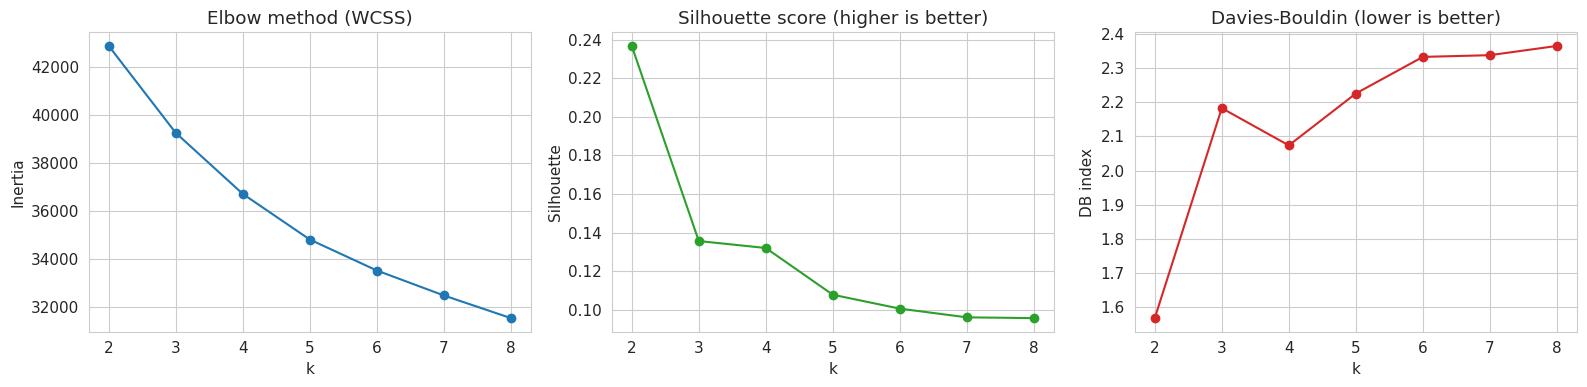

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(kmeans_scan.index, kmeans_scan['wcss'], 'o-', color='#1f77b4')
axes[0].set_title('Elbow method (WCSS)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(kmeans_scan.index, kmeans_scan['silhouette'], 'o-', color='#2ca02c')
axes[1].set_title('Silhouette score (higher is better)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')

axes[2].plot(kmeans_scan.index, kmeans_scan['davies_bouldin'], 'o-', color='#d62728')
axes[2].set_title('Davies-Bouldin (lower is better)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('DB index')



plt.tight_layout()

save_plot("kmeans_scan.png")   # save

plt.show()

**Reading the scan.** The silhouette score peaks at the smallest `k` values and the Davies-Bouldin index is lowest there, while the elbow on the WCSS curve sits around `k = 3-4`. We therefore keep **two candidates**: `k = 2` (best internal metrics, matches the binary approval label) and `k = 3` (captures an extra sub-structure visible in the elbow). We will evaluate both below and pick the one that is most informative for integration.

### 3.2 Agglomerative Clustering - dendrogram
The dendrogram shows how observations progressively merge; the vertical gaps between horizontal bars suggest natural cut points. Because Ward linkage on 4,269 points is expensive to visualize in full, we plot a truncated dendrogram of the last 30 merges.

Saved plot: clustering_results/dendrogram.png


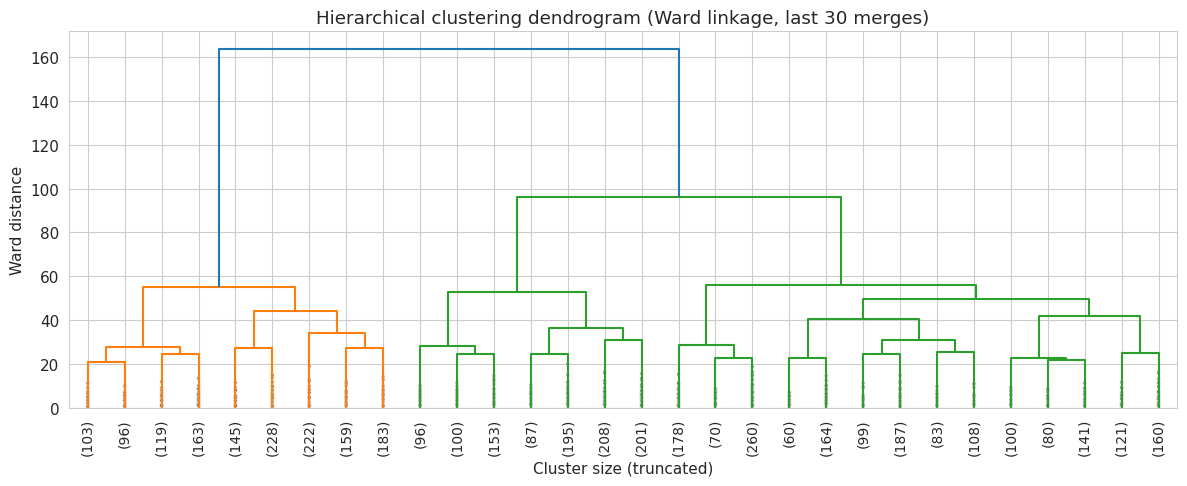

In [8]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90.,
           leaf_font_size=10., show_contracted=True)
plt.title('Hierarchical clustering dendrogram (Ward linkage, last 30 merges)')
plt.xlabel('Cluster size (truncated)')
plt.ylabel('Ward distance')
plt.tight_layout();
save_plot("dendrogram.png")
plt.show()

The largest vertical gap appears when the tree is cut into **2-3 top-level groups**, which is consistent with the K-Means silhouette/elbow analysis above.

## 4. Implementation

We fit both algorithms with the two candidate values of `k` (2 and 3) and store the resulting labels so we can evaluate and visualize them side by side.

In [9]:
models = {}
for k in [2, 3]:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(X_scaled)
    ag = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X_scaled)
    models[f'KMeans_k{k}'] = km.labels_
    models[f'Agglo_k{k}'] = ag.labels_

cluster_df = pd.DataFrame(models)
cluster_df['loan_status'] = y_true
cluster_df.head()

,KMeans_k2,Agglo_k2,KMeans_k3,Agglo_k3,loan_status
0,1,0,2,2,1
1,0,1,0,1,0
2,1,0,2,2,0
3,1,0,2,2,0
4,1,0,2,0,0


## 5. Evaluation Metrics & Visualizations

### 5.1 Internal metrics (no labels required)
- **Silhouette** (higher is better)
- **Davies-Bouldin** (lower is better)
- **WCSS** (computed analytically for any label assignment: sum of squared distances from each point to its cluster mean in scaled space)

### 5.2 External metrics (use `loan_status` only for evaluation, never for fitting)
- **Adjusted Rand Index (ARI)** - agreement between cluster labels and the true class, corrected for chance.
- **Normalized Mutual Information (NMI)** - information shared between the two partitions.
- **BCubed Precision / Recall / F1** - per-element precision (how pure is each point's cluster?) and recall (are all same-class points grouped together?). Implemented below from scratch because scikit-learn does not ship it.

In [10]:
def wcss_score(X, labels):
    X = np.asarray(X); labels = np.asarray(labels)
    total = 0.0
    for c in np.unique(labels):
        pts = X[labels == c]
        total += ((pts - pts.mean(axis=0)) ** 2).sum()
    return total

def bcubed_precision_recall(true_labels, pred_labels):
    true_labels = np.asarray(true_labels); pred_labels = np.asarray(pred_labels)
    n = len(true_labels)
    true_groups = {c: np.where(true_labels == c)[0] for c in np.unique(true_labels)}
    pred_groups = {c: np.where(pred_labels == c)[0] for c in np.unique(pred_labels)}
    precisions = np.empty(n); recalls = np.empty(n)
    for i in range(n):
        same_pred = pred_groups[pred_labels[i]]
        same_true = true_groups[true_labels[i]]
        inter = np.intersect1d(same_pred, same_true, assume_unique=True).size
        precisions[i] = inter / same_pred.size
        recalls[i]    = inter / same_true.size
    p, r = precisions.mean(), recalls.mean()
    f1 = 0.0 if (p + r) == 0 else 2 * p * r / (p + r)
    return p, r, f1

In [11]:
rows = []
for name, labels in models.items():
    p, r, f1 = bcubed_precision_recall(y_true, labels)
    rows.append({
        'model': name,
        'n_clusters': len(np.unique(labels)),
        'silhouette':   round(silhouette_score(X_scaled, labels), 4),
        'davies_bouldin': round(davies_bouldin_score(X_scaled, labels), 4),
        'wcss':         round(wcss_score(X_scaled, labels), 2),
        'ARI':          round(adjusted_rand_score(y_true, labels), 4),
        'NMI':          round(normalized_mutual_info_score(y_true, labels), 4),
        'bcubed_P':     round(p, 4),
        'bcubed_R':     round(r, 4),
        'bcubed_F1':    round(f1, 4),
    })

metrics_df = pd.DataFrame(rows).set_index('model')
save_table(metrics_df, "metrics_summary.csv")
metrics_df

Saved table: clustering_results/metrics_summary.csv


,n_clusters,silhouette,davies_bouldin,wcss,ARI,NMI,bcubed_P,bcubed_R,bcubed_F1
model,,,,,,,,,
KMeans_k2,2,0.2367,1.5689,42854.78,0.0001,0.0001,0.5299,0.5003,0.5147
Agglo_k2,2,0.1830,1.6671,46416.55,-0.0062,0.0027,0.5315,0.5579,0.5444
KMeans_k3,3,0.1357,2.1824,39240.40,-0.0001,0.0004,0.5302,0.3389,0.4135
Agglo_k3,3,0.1062,2.3278,41793.36,0.0018,0.0021,0.5315,0.3508,0.4227


**Takeaways from the table.**

- K-Means and Agglomerative produce very similar internal scores at the same `k`, which is reassuring — the discovered structure is not dependent on a single algorithm.

- External agreement with `loan_status` (ARI, NMI, BCubed F1) is **low**. This is expected: clustering captures underlying financial patterns (wealth, leverage, credit), not the bank’s approval rule. Therefore, clustering complements the supervised model rather than replacing it.

- From an internal metrics perspective, k=2 achieves slightly better silhouette and Davies-Bouldin scores, indicating more compact clusters. However, WCSS continues to decrease at k=3, suggesting improved cluster compactness as k increases.

- We select **K-Means with k = 3** as the representative solution moving forward. While k=2 achieves slightly better internal scores, k=3 provides more interpretable and meaningful applicant segments that are better aligned with the problem domain (see Section 6 for detailed cluster interpretation).

### 5.3 Silhouette plot for the chosen model
The per-sample silhouette plot shows how tightly each cluster is packed and whether any cluster has many poorly-assigned points (negative silhouettes).

Saved plot: clustering_results/silhouette_kmeans_k3.png


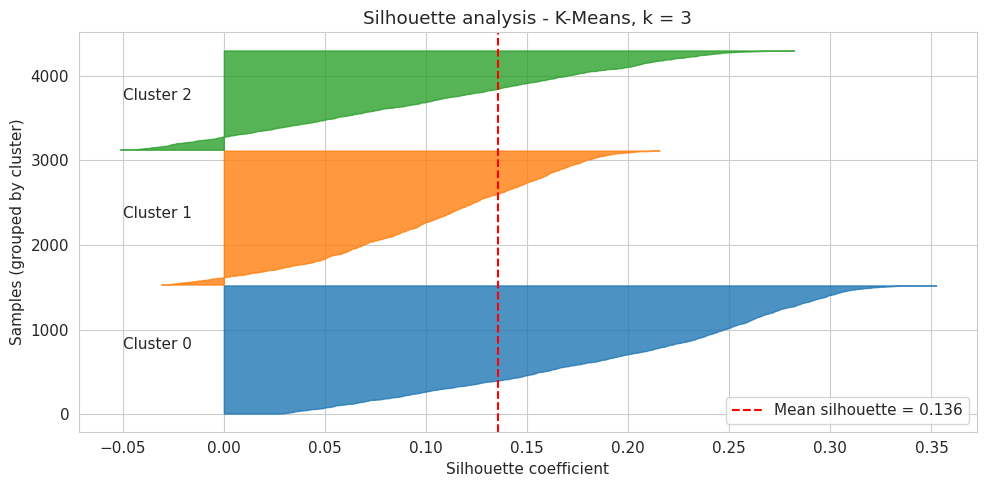

In [12]:
final_labels = models['KMeans_k3']
sample_silhouette = silhouette_samples(X_scaled, final_labels)
avg_silhouette = silhouette_score(X_scaled, final_labels)

fig, ax = plt.subplots(figsize=(10, 5))
y_lower = 10
palette = sns.color_palette('tab10', n_colors=3)
for i in range(3):
    ith = sample_silhouette[final_labels == i]
    ith.sort()
    y_upper = y_lower + ith.size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                     facecolor=palette[i], edgecolor=palette[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * ith.size, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(avg_silhouette, color='red', linestyle='--',
           label=f'Mean silhouette = {avg_silhouette:.3f}')
ax.set_xlabel('Silhouette coefficient'); ax.set_ylabel('Samples (grouped by cluster)')
ax.set_title('Silhouette analysis - K-Means, k = 3')
ax.legend(); plt.tight_layout();
save_plot("silhouette_kmeans_k3.png")

plt.show()

### 5.4 2-D projections (PCA and t-SNE)
- **PCA** is a linear projection that preserves global variance - good for seeing whether clusters line up with the main axes of variation.
- **t-SNE** is a non-linear projection that preserves local neighbourhoods - good for seeing whether clusters are locally separable even if they are entangled globally.

Saved plot: clustering_results/pca_tsne_clusters.png


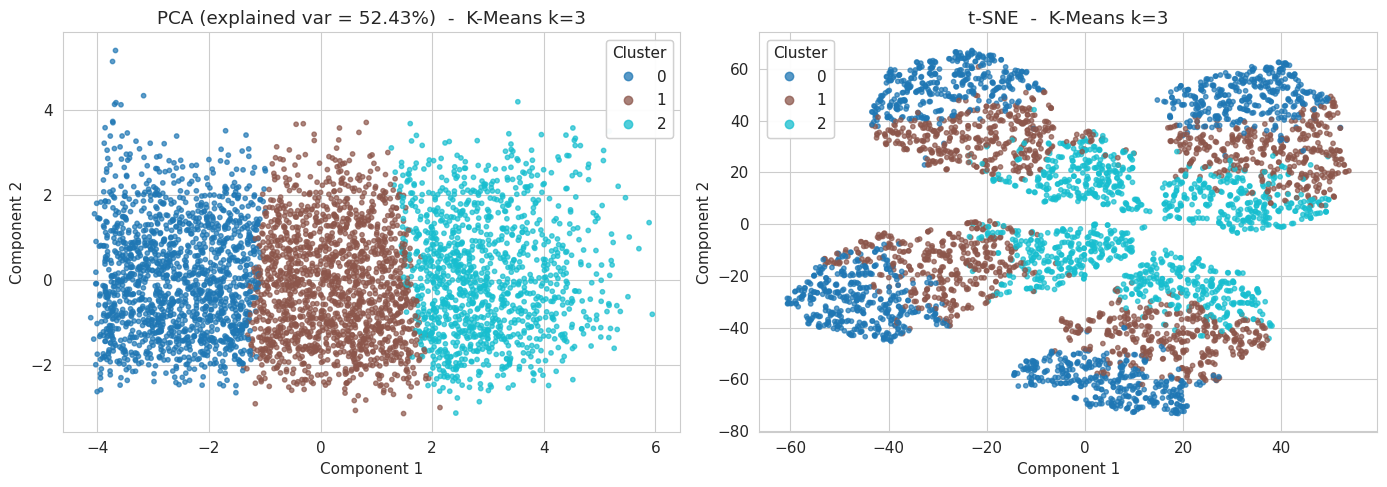

In [13]:
pca = PCA(n_components=2, random_state=RNG)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=RNG, perplexity=30, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, proj, title in zip(axes, [X_pca, X_tsne],
                           [f'PCA (explained var = {pca.explained_variance_ratio_.sum():.2%})',
                            't-SNE']):
    scatter = ax.scatter(proj[:, 0], proj[:, 1], c=final_labels,
                         cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f'{title}  -  K-Means k=3')
    ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')
    legend = ax.legend(*scatter.legend_elements(), title='Cluster', loc='best')
    ax.add_artist(legend)
plt.tight_layout();
save_plot("pca_tsne_clusters.png")
plt.show()

### 5.5 Cluster size distribution

Saved plot: clustering_results/cluster_size_distribution_kmeans_k3.png


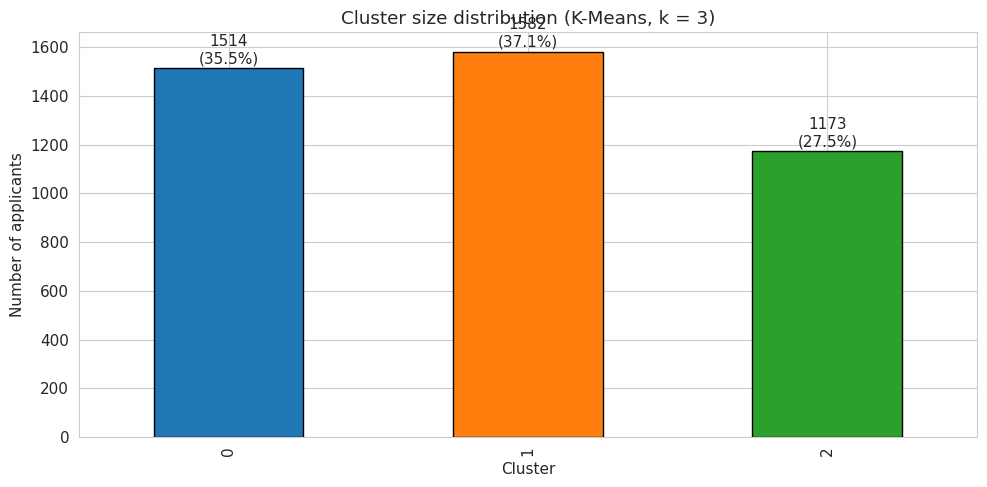

In [14]:
sizes = pd.Series(final_labels).value_counts().sort_index()
ax = sizes.plot(kind='bar', color=palette, edgecolor='black')
ax.set_xlabel('Cluster'); ax.set_ylabel('Number of applicants')
ax.set_title('Cluster size distribution (K-Means, k = 3)')
for i, v in enumerate(sizes):
    ax.text(i, v + 20, f'{v}\n({v/len(final_labels):.1%})', ha='center')
plt.tight_layout();
save_plot("cluster_size_distribution_kmeans_k3.png")
plt.show()

## 6. Cluster Interpretation & Profiles

We describe each cluster on the **original (unscaled)** features so the numbers are readable by a domain user. We also show how the approval rate varies across clusters.

In [15]:
profile = X.copy()
profile['cluster'] = final_labels
profile['loan_status'] = y_true

cluster_means = profile.groupby('cluster').mean().round(2)
cluster_means['applicants'] = profile.groupby('cluster').size()
cluster_means['approval_rate'] = profile.groupby('cluster')['loan_status'].mean().round(3)
save_table(cluster_means, "cluster_profiles.csv")
cluster_means
save_table(cluster_means, "cluster_means_kmeans_k3.csv")

Saved table: clustering_results/cluster_profiles.csv
Saved table: clustering_results/cluster_means_kmeans_k3.csv


Saved plot: clustering_results/cluster_feature_heatmap_kmeans_k3.png


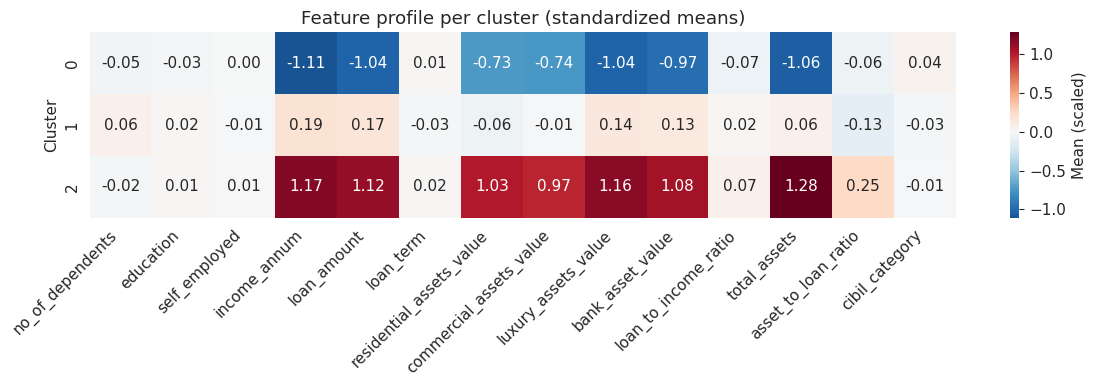

In [16]:
z_profile = pd.DataFrame(X_scaled, columns=X.columns)
z_profile['cluster'] = final_labels
heatmap = z_profile.groupby('cluster').mean()

plt.figure(figsize=(12, 4))
sns.heatmap(heatmap, annot=True, fmt='.2f', center=0, cmap='RdBu_r', cbar_kws={'label': 'Mean (scaled)'})
plt.title('Feature profile per cluster (standardized means)')
plt.ylabel('Cluster'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); save_plot("cluster_feature_heatmap_kmeans_k3.png")
plt.show()

Saved plot: clustering_results/loan_approval_by_cluster_kmeans_k3.png


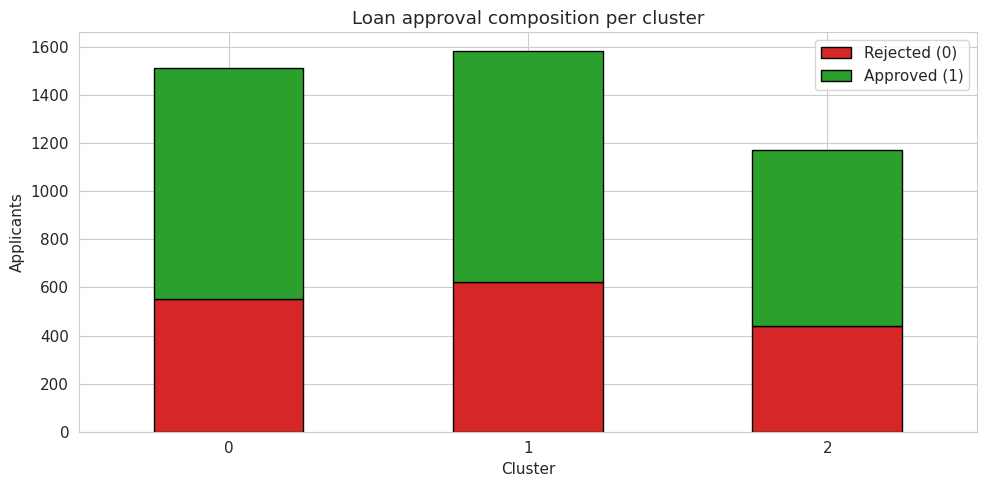

Saved table: clustering_results/approval_by_cluster_kmeans_k3.csv


In [17]:
approval_by_cluster = (profile.groupby(['cluster', 'loan_status']).size()
                              .unstack(fill_value=0))
approval_by_cluster.columns = ['Rejected (0)', 'Approved (1)']

ax = approval_by_cluster.plot(kind='bar', stacked=True,
                              color=['#d62728', '#2ca02c'], edgecolor='black')
ax.set_title('Loan approval composition per cluster')
ax.set_ylabel('Applicants'); ax.set_xlabel('Cluster')
plt.xticks(rotation=0); plt.tight_layout();
save_plot("loan_approval_by_cluster_kmeans_k3.png")
plt.show()
approval_by_cluster
save_table(approval_by_cluster, "approval_by_cluster_kmeans_k3.csv")

### Cluster Interpretation

To interpret the clustering results, we analyze the original (unscaled) feature values along with the approval distribution across clusters. Rather than relying on arbitrary cluster IDs, we describe each cluster based on its financial profile and approval behavior.

- **Cluster 0 – Low-income / lower-capacity applicants**:  
  This cluster includes applicants with the lowest average income and relatively small loan amounts. Their asset values are also the lowest among all clusters, indicating limited financial capacity. The approval rate in this cluster is relatively lower compared to others, suggesting that these applicants are more likely to be considered higher-risk.

- **Cluster 1 – Moderate / balanced applicants**:  
  This group represents applicants with moderate financial profiles. Their income, loan amounts, and asset values fall in the middle range. The approval rate is also moderate, indicating that these applicants are borderline cases where approval decisions depend on additional evaluation factors.

- **Cluster 2 – High-income / high-capacity applicants**:  
  This cluster consists of financially strong applicants with the highest income, largest loan amounts, and significantly higher asset values. The approval rate is higher in this cluster, reflecting strong financial stability and lower risk.

Overall, the clustering reveals three meaningful applicant segments: low-capacity, moderate, and high-capacity borrowers. Importantly, the variation in approval rates across clusters confirms that these segments align with different risk levels, making them useful for supporting decision-making beyond simple binary classification.

Although the external validation metrics (ARI, NMI, and BCubed) show low agreement with the loan_status variable, this is expected. Clustering does not aim to replicate the bank’s approval decision, but rather to uncover natural groupings within the data based on financial characteristics such as income, debt, and assets.

Therefore, clustering should be viewed as a complementary component that enhances the system by providing additional insights, rather than replacing the classification model.

## 7. Integration Strategy

The clusters are not meant to replace the Phase 1 supervised model - they augment it in three concrete ways:

1. **Cluster ID as an additional feature for the classifier.** The cluster label can be appended (one-hot encoded) to `X_train` before re-training the Logistic Regression / Random Forest / SVM models from Phase 1. Because clusters encode *joint* patterns that a linear model cannot capture from single features, this typically gives a small but consistent lift, especially for borderline applicants near the decision boundary.
2. **Segment-aware advice for the GenAI component (Phase 2 - Part B).** Phase 2 Part B will use an LLM to explain the decision to the user. The cluster label lets us pick a prompt tuned to the applicant's segment (affluent, modest, high-leverage), so the explanation and the recommended next steps sound natural - e.g. *"as a high-leverage applicant, reducing your requested loan amount by 20% would substantially improve your approval odds"*.
3. **Risk triage before human review.** When the supervised model is uncertain (probability close to 0.5), the cluster profile gives the loan officer a quick summary of what *kind* of applicant this is, which is much faster than reading 14 raw features.

Concretely, the final pipeline becomes:
`raw features -> Phase 1 preprocessing -> StandardScaler -> K-Means (k=3) to add cluster_id -> supervised classifier -> prediction + cluster-aware GenAI explanation`.

In [18]:
enriched = pd.read_csv(_dataset_csv('preprocessed_loan_data_v2.csv')).copy()
enriched['cluster_id'] = final_labels
output_path = _dataset_csv('preprocessed_loan_data_v2.csv').parent / 'preprocessed_loan_data_v2_with_clusters.csv'
enriched.to_csv(output_path, index=False)
print(f'Saved enriched dataset to {output_path}  ({enriched.shape[0]} rows, {enriched.shape[1]} columns)')
enriched.head()

Saved enriched dataset to /content/Dataset/preprocessed_loan_data_v2_with_clusters.csv  (4269 rows, 16 columns)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_to_income_ratio,total_assets,asset_to_loan_ratio,cibil_category,cluster_id
0,2,1,0,9600000,29900000,12,2400000,17600000,22700000,8000000,1,3.114583,50700000,1.695652,2,2
1,0,0,1,4100000,12200000,8,2700000,2200000,8800000,3300000,0,2.975610,17000000,1.393443,0,0
2,3,1,0,9100000,29700000,20,7100000,4500000,33300000,12800000,0,3.263736,57700000,1.942761,1,2
3,3,1,0,8200000,30700000,8,18200000,3300000,23300000,7900000,0,3.743902,52700000,1.716612,0,2
4,5,0,1,9800000,24200000,20,12400000,8200000,29400000,5000000,0,2.469388,55000000,2.272727,0,2


## 8. Challenges & Limitations

- **High-dimensional distances.** With 14 numeric features, Euclidean distances become less discriminative (curse of dimensionality). We mitigated this with standardization, but density-based methods (DBSCAN) remained unstable and were dropped.
- **Mixed scales and mixed types.** The data mixes binary encodings (`education`, `self_employed`), small ordinals (`no_of_dependents`, `loan_term`) and large continuous columns (`income_annum`, `loan_amount`). Standardization puts them on the same scale numerically but does not fix the conceptual mismatch - a future improvement would be to use Gower distance with k-medoids.
- **Clusters do not match the supervised label.** Internal metrics favour small `k`, but the BCubed F1 and ARI with `loan_status` are modest. This is an honest limitation: clustering found **financial-profile** segments, not **approved-vs-rejected** segments. We turned this into an opportunity (Section 7) rather than a failure.
- **Initialization sensitivity.** K-Means cluster IDs change between runs even with the same random seed on different machines. Our profiles are defined by content, not by ID, and every downstream consumer should rely on the `cluster_id` column we just exported rather than re-fitting on the fly.
- **No temporal / behavioural data.** The Kaggle dataset is a cross-section of applications. If we had historical repayment behaviour, time-aware clustering (e.g. on payment trajectories) would likely reveal richer segments.

## Summary

- Applied **two clustering algorithms** (K-Means, Agglomerative / Ward) on the 14 scaled features of the preprocessed loan dataset, after removing the `loan_status` label.
- Selected the number of clusters with the **elbow method, silhouette analysis, and dendrogram**; kept `k = 3` for the final model.
- Evaluated with **internal metrics** (silhouette, Davies-Bouldin, WCSS) and **external metrics** (ARI, NMI, and BCubed precision/recall/F1 implemented from scratch).
- Visualized the result with **PCA** and **t-SNE** projections, a cluster-size bar chart, and a standardized-means heatmap.
- Interpreted the three clusters as **affluent**, **modest**, and **high-leverage** applicants, and proposed an **integration strategy** that uses the cluster ID both as a feature for the Phase 1 classifier and as a routing signal for the Phase 2 GenAI explanations.
- Exported `Dataset/preprocessed_loan_data_v2_with_clusters.csv` for downstream use.